# Preparació del dataset de binders IL-7Rα

Aquest notebook construeix el dataset de referència experimental que s'utilitza com a etiquetes de classificació per a l'anàlisi estadística. Les dades provenen del repositori públic d'Adaptyv Bio associat a l'article original de RFdiffusion contra IL-7Rα, i s'integren tres fonts d'informació: les seqüències dels dissenys en format FASTA (IL7Ra_binders_sequences.fasta), els resultats del screening experimental (IL7Ra_binders_screening_results.csv) que indiquen si cada disseny és binder o non-binder, i les mesures cinètiques (kinetic_measurement_summary.csv) que proporcionen la força d'unió (strong/weak/none) i la constant de dissociació Kd per a un subconjunt de 42 dissenys. El dataset integrat final conté 95 dissenys i es guarda com a il7ra_binders_dataset.csv.

In [15]:
import re
import json
import pandas as pd

## 1. Càrrega de les seqüències (FASTA)

El fitxer FASTA es va descarregar com a pàgina HTML de GitHub; les seqüències es troben embegudes en un array JSON rawLines dins del codi font de la pàgina. S'extreuen amb una expressió regular i es transformen en un dataframe amb les columnes AF2_name (nom del disseny) i sequence.

In [16]:
fasta_path = "/Users/bertaguiu/Downloads/IL7Ra_binders_sequences.fasta"

with open(fasta_path, "r") as f:
    html = f.read()

# Sequences are embedded as a JSON array of strings inside the HTML
match = re.search(r'"rawLines":\[(.+?)\]', html)
if not match:
    raise ValueError("Could not find rawLines in FASTA/HTML file")

lines = json.loads("[" + match.group(1) + "]")

records = []
for i in range(0, len(lines) - 1, 2):
    header = lines[i].lstrip(">")
    sequence = lines[i + 1]
    records.append({"AF2_name": header, "sequence": sequence})

df_fasta = pd.DataFrame(records)
print(f"Parsed {len(df_fasta)} sequences")
df_fasta.head()

Parsed 95 sequences


,AF2_name,sequence
0,IL7Ra_binder_AF2_1,ELKELEEAVRAIKTARMRIEKDPSVAKEELEKVIEKLEKAAEVVSN...
1,IL7Ra_binder_AF2_2,EREEQIEEAIELFIKRAKELGAKEVKYEGNKITVKAPTKEVYEALK...
2,IL7Ra_binder_AF2_3,DALKEASKLMSEALLKEAEETTDEETKEALRKMAELVKAEKPEVLE...
3,IL7Ra_binder_AF2_4,AAEKAEEVVRALREAVERAVELIKKDAKKGAKEARRRLEEVAELAA...
4,IL7Ra_binder_AF2_5,EEKEKAKEIIDRAVKEAKKEAEKEDEETKKKTLEIIERAELVVKAD...


## 2. Resultats del screening experimental

Es carrega el CSV de resultats del screening, que conté per a cada disseny el nom RFdiffusion, el nom AF2 i la classificació binària com a binder (True) o non-binder (False), determinada a partir d'un llindar de resposta del 50% respecte al control positiu.

In [17]:
screening_path = "/Users/bertaguiu/Downloads/IL7Ra_binders_screening_results.csv"

df_screening = pd.read_csv(screening_path, index_col=0)
df_screening = df_screening[["RFdiffusion_output", "AF2_prediction", "Binder"]].rename(
    columns={"Binder": "is_binder"}
)

print(f"{len(df_screening)} screening entries")
df_screening.head()

95 screening entries


,RFdiffusion_output,AF2_prediction,is_binder
0,IL7Ra_binder_design_1,IL7Ra_binder_AF2_1,True
1,IL7Ra_binder_design_2,IL7Ra_binder_AF2_2,True
2,IL7Ra_binder_design_3,IL7Ra_binder_AF2_3,False
3,IL7Ra_binder_design_4,IL7Ra_binder_AF2_4,False
4,IL7Ra_binder_design_5,IL7Ra_binder_AF2_5,False


## 3. Mesures cinètiques d'afinitat

Es carreguen les mesures de cinètica multi-cicle realitzades per Adaptyv Bio sobre un subconjunt de 42 dissenys. Per a cada disseny mesurat s'obté la força d'unió (strong, weak o none) i la constant de dissociació Kd en molar. Els dissenys no mesurats tindran aquests camps com a NaN en el dataset final.

In [18]:
kinetics_path = "/Users/bertaguiu/Downloads/kinetic_measurement_summary.csv"

df_kinetics = pd.read_csv(kinetics_path)
df_kinetics = df_kinetics[["Name", "Binder", "KD (M)"]].rename(
    columns={"Name": "RFdiffusion_output", "Binder": "binding_strength", "KD (M)": "Kd_M"}
)
# Drop blank / control rows
df_kinetics = df_kinetics[df_kinetics["RFdiffusion_output"].str.startswith("IL7Ra", na=False)]

print(f"{len(df_kinetics)} kinetic entries")
df_kinetics.head()

42 kinetic entries


,RFdiffusion_output,binding_strength,Kd_M
4,IL7Ra_binder_design_1,weak,2.15e-05
5,IL7Ra_binder_design_10,none,NaN
6,IL7Ra_binder_design_11,none,NaN
7,IL7Ra_binder_design_12,strong,6.40e-06
8,IL7Ra_binder_design_13,none,NaN


## 4. Integració de les tres fonts

Es realitzen dos merges successius: primer entre les seqüències FASTA i els resultats del screening (per AF2_name / AF2_prediction), i després amb les mesures cinètiques (per RFdiffusion_output). El join amb les cinètiques és opcional (left join), de manera que es conserven els 95 dissenys del screening tot i que no tots tinguin Kd mesurat.

In [19]:
# Merge FASTA sequences into screening results
df = df_screening.merge(
    df_fasta,
    left_on="AF2_prediction",
    right_on="AF2_name",
    how="left"
).drop(columns="AF2_name")

# Merge kinetic data
df = df.merge(
    df_kinetics,
    on="RFdiffusion_output",
    how="left"
)

# Clean up column order
df = df.rename(columns={"RFdiffusion_output": "name", "AF2_prediction": "AF2_name"})[
    ["name", "AF2_name", "sequence", "is_binder", "binding_strength", "Kd_M"]
].reset_index(drop=True)

print(f"Final dataset: {len(df)} rows")
df.head(10)

Final dataset: 95 rows


,name,AF2_name,sequence,is_binder,binding_strength,Kd_M
0,IL7Ra_binder_design_1,IL7Ra_binder_AF2_1,ELKELEEAVRAIKTARMRIEKDPSVAKEELEKVIEKLEKAAEVVSN...,True,weak,2.15e-05
1,IL7Ra_binder_design_2,IL7Ra_binder_AF2_2,EREEQIEEAIELFIKRAKELGAKEVKYEGNKITVKAPTKEVYEALK...,True,weak,> 1e-6
2,IL7Ra_binder_design_3,IL7Ra_binder_AF2_3,DALKEASKLMSEALLKEAEETTDEETKEALRKMAELVKAEKPEVLE...,False,none,NaN
3,IL7Ra_binder_design_4,IL7Ra_binder_AF2_4,AAEKAEEVVRALREAVERAVELIKKDAKKGAKEARRRLEEVAELAA...,False,none,NaN
4,IL7Ra_binder_design_5,IL7Ra_binder_AF2_5,EEKEKAKEIIDRAVKEAKKEAEKEDEETKKKTLEIIERAELVVKAD...,False,weak,> 1e-6
5,IL7Ra_binder_design_6,IL7Ra_binder_AF2_6,EEKKKEIKEEAEKKAEEAFPKDKEEALKVKMAIDAIYRAKTKESRE...,False,weak,> 1e-6
6,IL7Ra_binder_design_7,IL7Ra_binder_AF2_7,AMEEVEKLLEEAGKYAQKAMELDPSIAKEVAQLMHDVLEALSEHKD...,False,weak,> 1e-6
7,IL7Ra_binder_design_8,IL7Ra_binder_AF2_8,MAVVTAPDTPDVREFAEKVAKYYGWEKYKEGDKIVIKCDSLEIAEQ...,True,strong,6.60e-06
8,IL7Ra_binder_design_9,IL7Ra_binder_AF2_9,MEVKEKAAEIVLKAGEEAAKDPSKAAEIWREAAKEVWTLIEEEIGE...,True,weak,> 1e-6
9,IL7Ra_binder_design_10,IL7Ra_binder_AF2_10,SVQLEALEILIKELKKELEKAKKELEKASPEEKKKLEEKAKKLEEL...,False,none,NaN


In [20]:
print("=== Binder distribution ===")
print(df["is_binder"].value_counts().to_string())

print("\n=== Binding strength (kinetically measured) ===")
print(df["binding_strength"].value_counts(dropna=False).to_string())

print("\n=== Kd (M) summary (strong binders only) ===")
strong = df[df["binding_strength"] == "strong"].copy()
# Convert numeric Kd values only
strong["Kd_numeric"] = pd.to_numeric(strong["Kd_M"], errors="coerce")
print(strong["Kd_numeric"].describe().to_string())

=== Binder distribution ===
False    63
True     32

=== Binding strength (kinetically measured) ===
NaN       53
strong    19
weak      15
none       8

=== Kd (M) summary (strong binders only) ===
count    1.900000e+01
mean     1.254779e-06
std      2.309877e-06
min      4.000000e-08
25%      8.560000e-08
50%      1.790000e-07
75%      5.930000e-07
max      6.600000e-06


## 5. Visualització del dataset

Es generen cinc gràfics per tenir una visió general de les característiques del dataset: el balanç de classes binder/non-binder, la distribució de la força d'unió mesurada per cinètica, la sobreposició entre les dues classificacions (screening vs. cinètica), la distribució de Kd en escala logarítmica per comprovar si hi ha bimodalitat entre binders forts i febles, i la distribució de la longitud de seqüència. Aquests gràfics permeten avaluar la qualitat i l'homogeneïtat del dataset abans de l'anàlisi estadística.

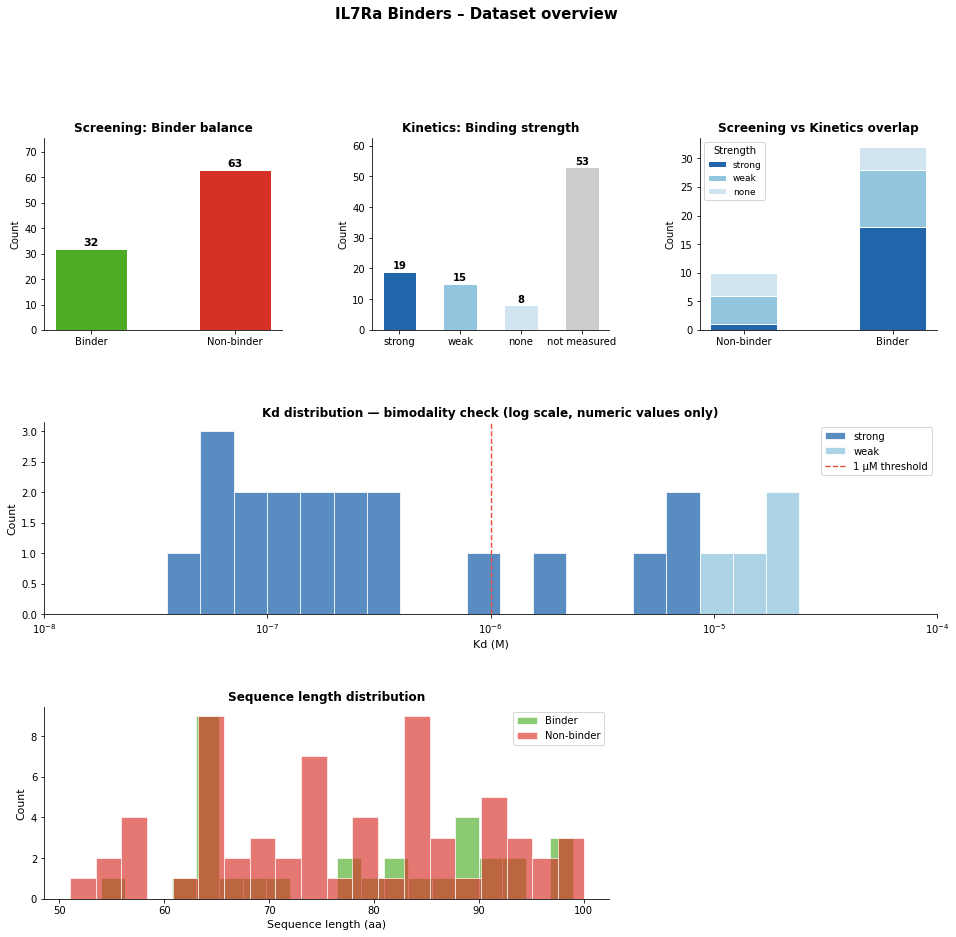

Figure saved.


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Derived columns
df["seq_len"] = df["sequence"].str.len()
df["Kd_numeric"] = pd.to_numeric(df["Kd_M"], errors="coerce")

strength_order  = ["strong", "weak", "none"]
strength_colors = {"strong": "#2166ac", "weak": "#92c5de", "none": "#d1e5f0"}
binder_colors   = ["#4dac26", "#d73027"]

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

# --- 1. Binder balance ---
ax1 = fig.add_subplot(gs[0, 0])
counts = df["is_binder"].value_counts().reindex([True, False])
bars = ax1.bar(["Binder", "Non-binder"], counts.values,
               color=binder_colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
             str(val), ha="center", va="bottom", fontsize=11, fontweight="bold")
ax1.set_title("Screening: Binder balance", fontsize=12, fontweight="bold")
ax1.set_ylabel("Count")
ax1.set_ylim(0, counts.max() * 1.2)
ax1.spines[["top", "right"]].set_visible(False)

# --- 2. Binding strength distribution ---
ax2 = fig.add_subplot(gs[0, 1])
measured    = df[df["binding_strength"].notna()]
str_counts  = measured["binding_strength"].value_counts().reindex(strength_order, fill_value=0)
not_meas    = df["binding_strength"].isna().sum()
all_labels  = strength_order + ["not measured"]
all_values  = list(str_counts.values) + [not_meas]
all_colors  = [strength_colors[s] for s in strength_order] + ["#cccccc"]
bars2 = ax2.bar(all_labels, all_values, color=all_colors, edgecolor="white", width=0.55)
for bar, val in zip(bars2, all_values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_title("Kinetics: Binding strength", fontsize=12, fontweight="bold")
ax2.set_ylabel("Count")
ax2.set_ylim(0, max(all_values) * 1.18)
ax2.spines[["top", "right"]].set_visible(False)

# --- 3. Crosstab: is_binder × binding_strength ---
ax3 = fig.add_subplot(gs[0, 2])
ct = pd.crosstab(df["is_binder"], df["binding_strength"])
ct = ct.reindex(columns=[c for c in strength_order if c in ct.columns])
ct.index = ["Non-binder", "Binder"]
bottom = np.zeros(len(ct))
for col in ct.columns:
    ax3.bar(ct.index, ct[col], bottom=bottom,
            label=col, color=strength_colors[col], edgecolor="white", width=0.45)
    bottom += ct[col].values
ax3.set_title("Screening vs Kinetics overlap", fontsize=12, fontweight="bold")
ax3.set_ylabel("Count")
ax3.legend(title="Strength", fontsize=9)
ax3.spines[["top", "right"]].set_visible(False)

# --- 4. Kd histogram (log scale) — bimodality check ---
ax4 = fig.add_subplot(gs[1, :])
kd_data = df.dropna(subset=["Kd_numeric"])
log_kd  = np.log10(kd_data["Kd_numeric"])
bins    = np.linspace(log_kd.min() - 0.2, log_kd.max() + 0.2, 22)
for strength in strength_order:
    sub = kd_data[kd_data["binding_strength"] == strength]
    if len(sub):
        ax4.hist(np.log10(sub["Kd_numeric"]), bins=bins, alpha=0.75,
                 color=strength_colors[strength], label=strength, edgecolor="white")
ax4.axvline(np.log10(1e-6), color="#e74c3c", linestyle="--", linewidth=1.4, label="1 µM threshold")
xticks = np.arange(int(np.floor(log_kd.min())), int(np.ceil(log_kd.max())) + 1)
ax4.set_xticks(xticks)
ax4.set_xticklabels([f"10$^{{{t}}}$" for t in xticks])
ax4.set_xlabel("Kd (M)", fontsize=11)
ax4.set_ylabel("Count", fontsize=11)
ax4.set_title("Kd distribution — bimodality check (log scale, numeric values only)", fontsize=12, fontweight="bold")
ax4.legend(fontsize=10)
ax4.spines[["top", "right"]].set_visible(False)

# --- 5. Sequence length distribution ---
ax5 = fig.add_subplot(gs[2, 0:2])
for is_b, label, color in [(True, "Binder", "#4dac26"), (False, "Non-binder", "#d73027")]:
    sub = df[df["is_binder"] == is_b]["seq_len"]
    ax5.hist(sub, bins=20, alpha=0.65, color=color, label=label, edgecolor="white")
ax5.set_xlabel("Sequence length (aa)", fontsize=11)
ax5.set_ylabel("Count", fontsize=11)
ax5.set_title("Sequence length distribution", fontsize=12, fontweight="bold")
ax5.legend(fontsize=10)
ax5.spines[["top", "right"]].set_visible(False)

plt.suptitle("IL7Ra Binders – Dataset overview", fontsize=15, fontweight="bold", y=1.01)
plt.savefig("/Users/bertaguiu/projects/Scripts/il7ra_binders_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 6. Exportació del dataset

El dataset integrat es guarda com a il7ra_binders_dataset.csv i s'utilitza posteriorment per afegir les etiquetes de classificació al dataset de mètriques computacionals.

In [22]:
output_path = "/Users/bertaguiu/projects/Scripts/il7ra_binders_dataset.csv"
df.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to /Users/bertaguiu/projects/Scripts/il7ra_binders_dataset.csv
